## **Reflections- week 1 - week 4**   

- In all cases, written answers (apart from code) should not be longer than about three paragraphs.  

- Graders may not read all of your submission if it is longer than that.


In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

### **Homework reflection 1**


**1. In Coding Quiz 1, you are asked to find the distance of the farthest match in a set. Is this farthest match distance too far to be a meaningful match? How can you decide this?**

The farthest match distance is 0.2102, but this number alone does not tell us whether the match is too far because it depends on the scale of `Z`.

I would first standardize the matching distance by dividing it by the standard deviation of `Z`. Then I would compare the standardized distance with a chosen caliper, which is the maximum acceptable matching distance. For example, using a caliper of 0.2 on the standardized scale means that any raw matching distance greater than `0.2 × SD(Z)` would be rejected.

I would also check whether this caliper gives good balance between the treatment and matched control groups without leaving too many treatment observations unmatched.     
 


**2. In Coding Quiz 1, there are two approaches to matching:(A) Picking the best match X = 0 corresponding to each X = 1 using Z values.(B) Using radius_neighbors to pick all matches X = 0 within a distance of 0.2 of each X = 1. Invent your own type of matching similar to 1 and 2 (or look one up on the internet), which has a different way to pick the matches in X = 0. Clearly explain the approach you invented or found.**

Another approach is k-nearest-neighbor matching with a caliper. For each treatment observation, I would find the `k` control observations with the closest values of `Z`. Then I would keep only the controls whose distance is within the chosen caliper, so very distant matches are not used. For example, if `k = 3`, a treatment observation could be matched with up to three nearby controls. I would then use the average `Y` value of the matched controls as the comparison outcome for that treatment observation. This is different from using only one nearest control or using every control within a fixed radius.

___

### **Homework reflection 2**


**1. Invent an example situation that would use fixed effects.**

For example, I could study how work hours affect employee sales in different stores. Some stores may naturally have higher sales because they are in better locations, have more customers, or have different managers.   
If I ignore these differences, I may get the wrong idea about the effect of work hours. A fixed effects model can give each store its own baseline sales level and then estimate the common effect of work hours on sales.   
This helps separate the store differences from the effect of work hours.

**2. Write a Python program that performs a bootstrap simulation to find the variance in the mean of the Pareto distribution when different samples are taken.  Explain what you had to do for this.  As you make the full sample size bigger (for the same distribution), what happens to the variance of the mean of the samples?  Does it stay about the same, get smaller, or get bigger?**

In [2]:
np.random.seed(42)

def bootstrap_pareto_mean_variance(sample_size, shape_param=3, num_bootstraps=1000):

    sample = np.random.pareto(a=shape_param, size=sample_size) + 1
    
    # 2. Perform Bootstrap Simulation
    bootstrap_means = []
    for _ in range(num_bootstraps):
        
        boot_sample = np.random.choice(sample, size=sample_size, replace=True)
        bootstrap_means.append(np.mean(boot_sample))
    
    # 3. Calculate the variance of the bootstrap sample means
    mean_variance = np.var(bootstrap_means, ddof=1)
    return mean_variance

# Evaluate variance across increasing sample sizes
sample_sizes = [100, 200, 500, 1000, 2000, 5000, 10000]

print("Sample Size (N) | Variance of Sample Mean")
print("-" * 40)
for N in sample_sizes:
    var_mean = bootstrap_pareto_mean_variance(sample_size=N)
    print(f"{N:15d} | {var_mean:.6f}")

Sample Size (N) | Variance of Sample Mean
----------------------------------------
            100 | 0.002921
            200 | 0.004311
            500 | 0.000946
           1000 | 0.000578
           2000 | 0.000280
           5000 | 0.000116
          10000 | 0.000109


I first generated a sample from a Pareto distribution with a shape parameter of 3. For each sample size, I repeatedly created bootstrap samples by sampling with replacement from the original sample. I calculated the mean of each bootstrap sample and then calculated the variance of all of those means.

As the full sample size became larger, the variance of the sample means generally became smaller. It did not decrease at every single step because the samples are random, but the overall pattern was clear. Larger samples gave more stable estimates of the mean, so the variance of the means decreased.

____

### **Homework reflection 3**


**1. In the event study in Coding Quiz 3, how would we go about testing for a change in the second derivative as well?**

To test for a change in the second derivative, I would add a quadratic time term to the event-study model. For example, I could use `(time - 50)^2` and interact it with the `after-event indicator`. This would let the model capture a change in curvature after the event. I would then look at the coefficient and p-value of that interaction term to see if the second derivative changed significantly after the event.


**2. Create your own scenario that illustrates differences-in-differences. Describe the story behind the data and show whether there is a nonzero treatment effect.**  

One simple example would be two similar stores, where one store starts a new advertising campaign and the other store does not. Before the campaign, the treatment store had sales of 100 and the control store had sales of 80. After the campaign, their sales increased to 130 and 100.

The treatment store increased by 30, while the control store increased by 20. The difference-in-differences estimate is 30 - 20 = 10. This means the treatment effect is nonzero, and the advertising campaign is associated with an additional increase of 10 units in sales.

____

### **Homework reflection 4**


**1. The Coding Quiz gives two options for instrumental variables.  For the second item (dividing the range of W into multiple ranges), explain how you did it, show your code, and discuss any issues you encountered.**  


For the second IV method, I divided W into several smaller ranges and calculated the IV effect separately within each range. For each W range, I grouped the observations by Z, calculated the mean X and Y for Z = 0 and Z = 1, and then calculated the effect as the change in Y divided by the change in X. Finally, I averaged the effects across the W ranges.

I initially tried `pd.cut()`, which divides the numerical range of W into equal-width intervals. However, when I increased the number of bins, some ranges had very few observations and the estimates became unstable. I therefore used `pd.qcut()` so that each range contained roughly the same number of observations. I also tried several numbers of bins to check whether the result was sensitive to this choice. The estimates stayed close to 1.5; for example, using 10 ranges gave an estimated effect of about 1.51.

The results were approximately 1.516, 1.509, 1.506, 1.503, 1.510, and 1.510 for 5, 10, 20, 30, 40, and 50 ranges, respectively. Since the estimates were very similar, the result appeared to be fairly stable across different numbers of W ranges.


In [3]:
df = pd.read_csv("data/homework_4.1.csv")

n_bins = [5, 10, 20, 30, 40, 50]

results = {}

for n in n_bins:

    df_n = df.copy()
    df_n["W_bin"] = pd.qcut(df_n["W"], q=n)

    effects = []

    for _, group in df_n.groupby("W_bin", observed=True):

        means = group.groupby("Z")[["X", "Y"]].mean()

        delta_y = means.loc[1, "Y"] - means.loc[0, "Y"]
        delta_x = means.loc[1, "X"] - means.loc[0, "X"]

        effects.append(delta_y / delta_x)

    results[n] = np.mean(effects)

results

{5: np.float64(1.5156437668194975),
 10: np.float64(1.508896371522371),
 20: np.float64(1.5055261177415453),
 30: np.float64(1.5028133965472348),
 40: np.float64(1.5103996612369919),
 50: np.float64(1.5096011303207189)}

**2. Plot the college outcome (Y) vs. the test score (X) in a small range of test scores around 80. On the plot, compare it with the Y probability predicted by logistic regression. The ground truth Y value is 0 or 1; don't just plot 0 or 1 - that will make it unreadable.  Find some way to make it look better than that.**  

In [4]:
df2a = pd.read_csv('./data/homework_4.2.a.csv')
df2b = pd.read_csv('./data/homework_4.2.b.csv')


In [5]:
# Small window around the cutoff
df_local = df2a[(df2a["X"] >= 75) & (df2a["X"] <= 85)].copy()

# RD features
df_local["centered_X"] = df_local["X"] - 80
df_local["treated"] = (df_local["X"] >= 80).astype(int)
df_local["interaction"] = df_local["centered_X"] * df_local["treated"]

# Logistic regression
X_logit = df_local[["centered_X", "treated", "interaction"]]
X_logit = sm.add_constant(X_logit)

logit_model = sm.Logit(df_local["Y"], X_logit).fit()
df_local["pred_prob"] = logit_model.predict(X_logit)
print(logit_model.summary())

Optimization terminated successfully.


         Current function value: 0.643780
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                38276
Model:                          Logit   Df Residuals:                    38272
Method:                           MLE   Df Model:                            3
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.06545
Time:                        00:51:58   Log-Likelihood:                -24641.
converged:                       True   LL-Null:                       -26367.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.8011      0.031    -25.882      0.000      -0.862      -0.740
centered_X      0.0098      0.011      0.893      0.372      -0

In [6]:
df_local["X_bin"] = pd.cut(df_local["X"],bins=20)
observed = (df_local.groupby("X_bin", observed=True).agg(X_mean=("X", "mean"),Y_prob=("Y", "mean")).reset_index())
observed

,X_bin,X_mean,Y_prob
0,"(74.99, 75.5]",75.251123,0.288813
1,"(75.5, 76.0]",75.750063,0.299837
2,"(76.0, 76.5]",76.248930,0.301051
3,"(76.5, 77.0]",76.751016,0.310825
4,"(77.0, 77.5]",77.252116,0.318750
5,"(77.5, 78.0]",77.750129,0.317477
6,"(78.0, 78.5]",78.251066,0.289773
7,"(78.5, 79.0]",78.747426,0.304632
8,"(79.0, 79.5]",79.255894,0.292779
9,"(79.5, 80.0]",79.752060,0.321682


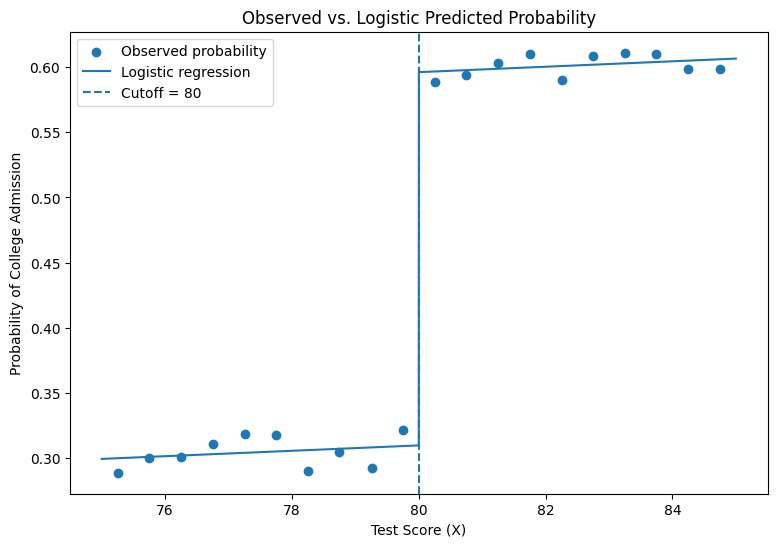

In [7]:
df_plot = df_local.sort_values("X")
plt.figure(figsize=(9, 6))

# Ground truth as observed probability
plt.scatter(observed["X_mean"],observed["Y_prob"],label="Observed probability")

# Logistic predicted probability
plt.plot(df_plot["X"],df_plot["pred_prob"],label="Logistic regression")

# Cutoff
plt.axvline(80,linestyle="--",label="Cutoff = 80")

plt.xlabel("Test Score (X)")
plt.ylabel("Probability of College Admission")
plt.title("Observed vs. Logistic Predicted Probability")
plt.legend()

plt.show()

Because Y is binary, plotting every observation directly at 0 or 1 would make the graph difficult to read.   
I divided the test scores between 75 and 85 into small bins and calculated the average Y within each bin. Since Y is either 0 or 1, the average represents the observed probability of college admission.

I then fit a logistic regression using the centered test score, treatment indicator, and their interaction, and plotted its predicted probabilities using the original test-score values.   
The observed probabilities were around 0.30 before the cutoff and around 0.60 after the cutoff.  
The logistic regression followed the same pattern and showed a clear jump at the cutoff of 80, while the slopes on either side were relatively flat.
